In [1]:
#correlation calculator for cell tracking data
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pdb
from scipy import integrate
import matplotlib as mpl
from scipy import interpolate
import time

from ABM_package import *
from PDE_FIND3 import * 
from model_selection_IP3 import *
import time, glob
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png', 'pdf')

import os
import pickle
import pandas as pd

import os
from correlation_package import *
from visualize_correlations import *

#increase font size throughout
font = {'size'   : 25}
plt.rc('font', **font)
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")  # Use GPU
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")   # Fallback to CPU
    print("GPU not available, using CPU")

Using GPU: NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
folder = "../VivariumData/extracted_cell_data.csv"
viv_df = pd.read_csv(folder)
viv_df.head()

,timepoint,cell_id,cell_type,cell_state,x_coord,y_coord,phenotype
0,0.0,tcell_0,tcell,PD1n,1544.338076,1122.457282,0
1,0.0,tcell_1,tcell,PD1n,1527.619794,916.044149,0
2,0.0,tcell_2,tcell,PD1n,1113.452666,331.704737,0
3,0.0,tcell_3,tcell,PD1p,228.186987,61.800221,1
4,0.0,tcell_4,tcell,PD1p,1734.940707,337.553663,1


In [13]:
# Compute correlations per frame
frames, corr_matrices, zero_counts_joint = correlations_by_framez(
    viv_df,
    frame_col='timepoint',       # adjust if your frame column has a different name
    x_col='x_coord',       # adjust if your x column is named differently
    y_col='y_coord',       # adjust if your y column is named differently
    label_col='phenotype',   # column with phenotype labels
    N=4,                     # number of phenotypes
    radius=35,                # neighborhood radius
    normalization="p_joint",  # use p-joint normalization
    return_zero_counts=True   # return zero counts
        )

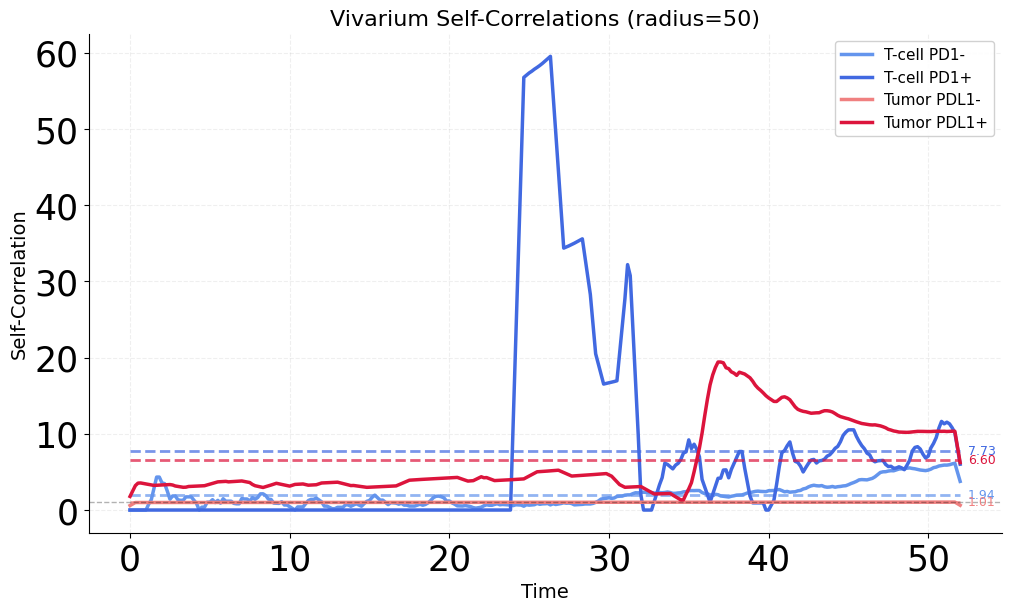

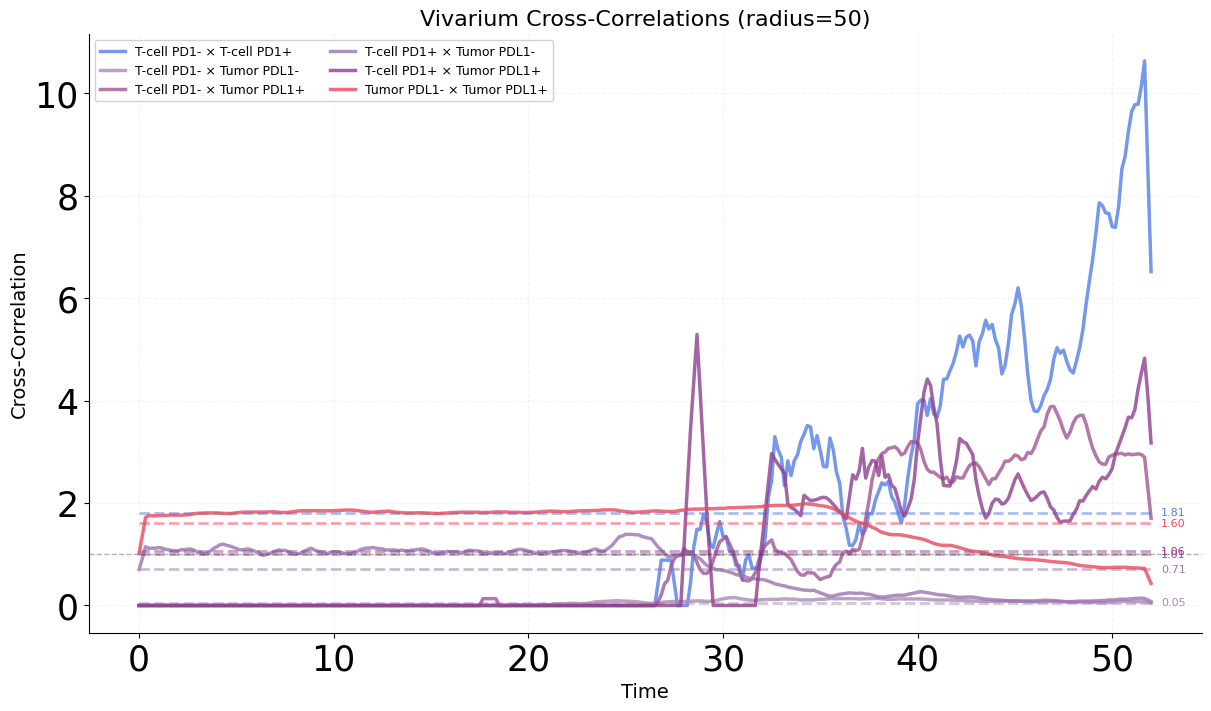

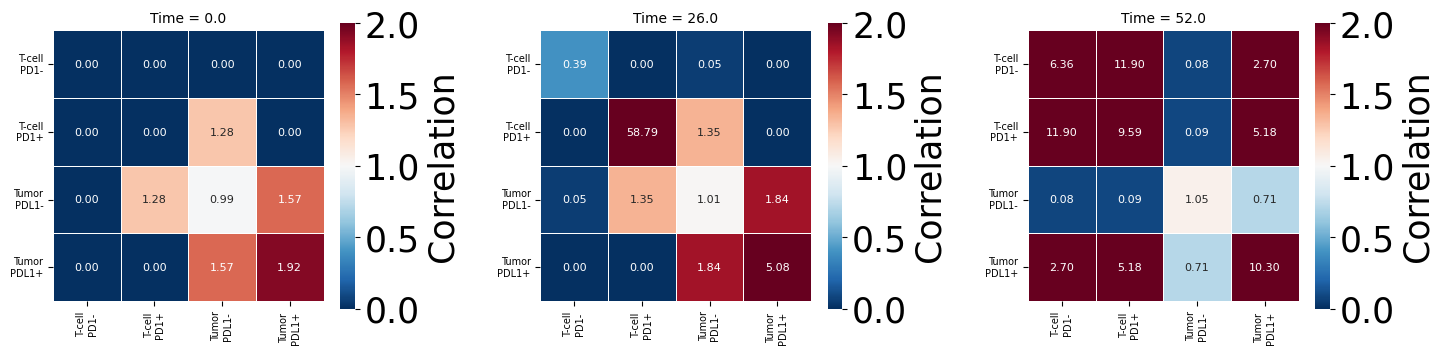

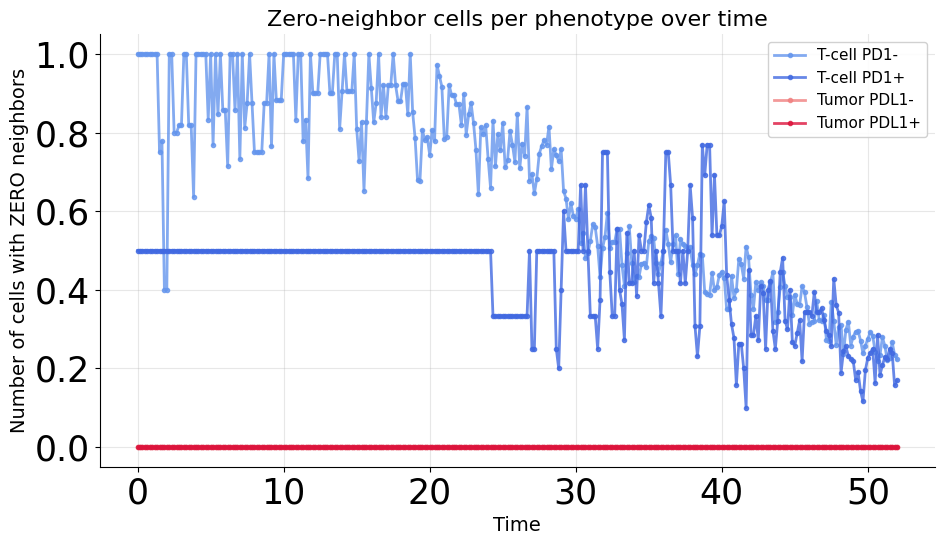

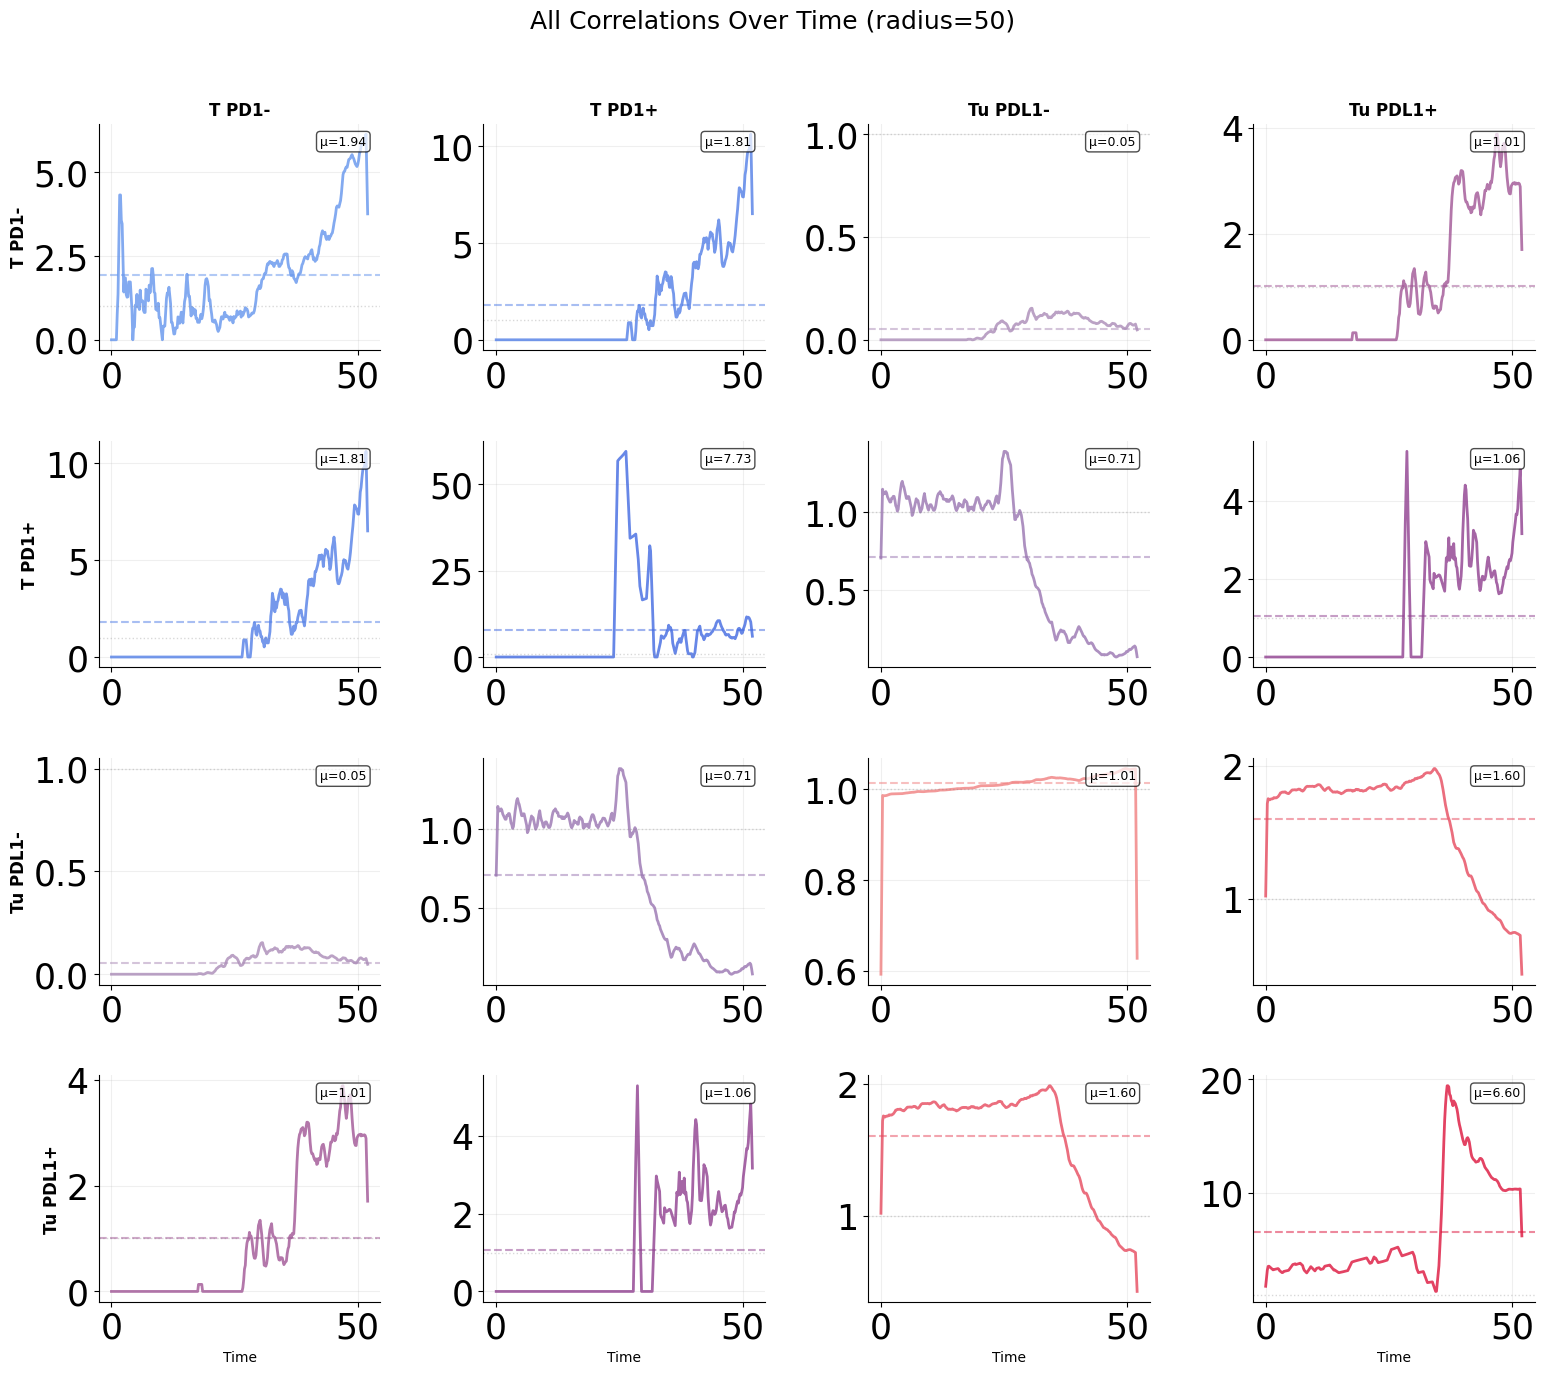


Mean Self-Correlations:
  T-cell PD1-         : 1.943
  T-cell PD1+         : 7.730
  Tumor PDL1-         : 1.013
  Tumor PDL1+         : 6.595


In [14]:
# Cell 3: Plot self-correlations


plot_self_correlations_vivarium(frames, corr_matrices, radius=50, window=5)
plt.show()

# Cell 4: Plot cross-correlations
plot_cross_correlations_vivarium(frames, corr_matrices, radius=50, window=5)
plt.show()

# Cell 5: Plot heatmaps at specific timepoints
plot_correlation_heatmaps(frames, corr_matrices, timepoints=[0, 26, 52])
plt.show()

# Cell 6: Plot zero neighbor counts
plot_zero_counts_vivarium(frames, zero_counts_joint)
plt.show()

# Cell 7: Plot all correlations in a grid
plot_all_correlations_grid(frames, corr_matrices, radius=50, window=5)
plt.show()

# Cell 8: Print summary statistics
phenotype_labels = ["T-cell PD1-", "T-cell PD1+", "Tumor PDL1-", "Tumor PDL1+"]

print("\nMean Self-Correlations:")
for i in range(4):
    mean = np.mean(corr_matrices[:, i, i])
    print(f"  {phenotype_labels[i]:20s}: {mean:.3f}")



In [20]:
def moving_average(data, window):
    return np.convolve(data, np.ones(window)/window, mode='same')

def plot_self_correlations_viv(frames, corr_matrices, N, dataset_name="", radius=15, window=5, save_path=None):
    colors = {0: "blue", 1: "lightseagreen", 2: "lightcoral", 3: "mediumpurple"}
    labels = {0: "PD1n", 1: "PD1p", 2: "PDL1n", 3: "PDL1p"}

    fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
    ax.grid(True, linestyle='--', alpha=0.2)

    for i in range(N):
        smoothed = moving_average(corr_matrices[:, i, i], window=window)
        avg_line = np.mean(corr_matrices[:, i, i])

        # Smoothed line
        ax.plot(frames, smoothed, color=colors[i], linewidth=2.5)

        # Average line
        ax.plot(frames, [avg_line]*len(frames), color=colors[i], linewidth=2,
                linestyle='--', alpha=0.7)

        # Add a small text label at the last frame for average
        ax.text(frames[-1], avg_line, f"{avg_line:.2f}", color=colors[i],
                fontsize=9, va='bottom', ha='left')

    ax.axhline(1.0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel("Frame (time)", fontsize=12)
    ax.set_ylabel("Correlation", fontsize=12)
    ax.set_title("Self-Correlations (radius={radius})", fontsize=14)

    # Simplified legend: only color for phenotype, one note for average line
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color=colors[i], lw=3) for i in range(N)]
    custom_lines.append(Line2D([0], [0], color='k', lw=2, linestyle='--'))
    legend_labels = [labels[i] for i in range(N)] + ["-- = average"]
    ax.legend(custom_lines, legend_labels, fontsize=10, title="Legend", title_fontsize=11, loc='upper right')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=300)
    return fig

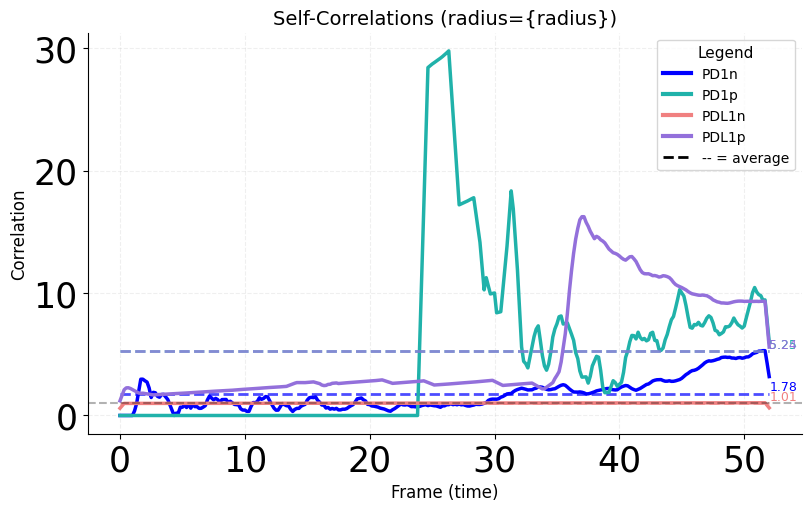

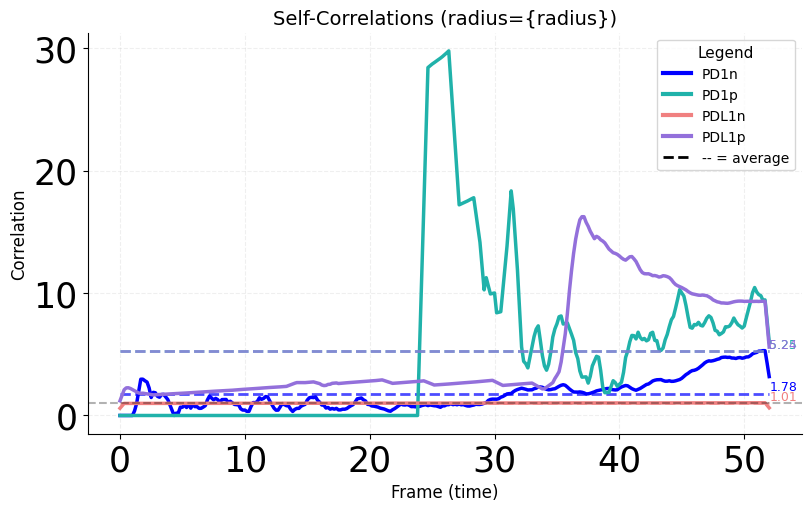

In [23]:
plot_self_correlations_viv(frames, corr_matrices, N=4, dataset_name="Vivarium", radius=50, window=5, save_path="vivarium_self_correlations.png")

In [261]:
folder= "../data/processed_coculture/"

c_dfs={}

import os
import pickle
import pandas as pd

folder = "../data/processed_coculture/"
c_dfs = {}

for fname in os.listdir(folder):
    if fname.endswith(".pkl"):
        full_path = os.path.join(folder, fname)
        
        with open(full_path, "rb") as f:
            obj = pickle.load(f)

        df = pd.DataFrame(obj)

        # Get base name without .pkl extension
        base_name = os.path.splitext(fname)[0]

        # Split by each unique experiment value
        unique_experiments = df['experiment'].unique()
        
        for exp in unique_experiments:
            df_exp = df[df['experiment'] == exp].reset_index(drop=True)
            key = f"{base_name}_{exp}"
            c_dfs[key] = df_exp
            print(f"Loaded {key} → {df_exp.shape} rows")


/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use 

Loaded Fibronectin_0_625_-40-F5-F05 → (35582, 18) rows
Loaded Fibronectin_0_625_-41-F6-F06 → (34416, 18) rows
Loaded Fibronectin_0_625_-42-F7-F07 → (47539, 18) rows
Loaded Plastic_0_313_-46-G2-G02 → (55613, 18) rows
Loaded Plastic_0_313_-47-G3-G03 → (45646, 18) rows
Loaded Plastic_0_313_-48-G4-G04 → (27519, 18) rows
Loaded Fibronectin_10_-04-B5-B05 → (551600, 18) rows
Loaded Fibronectin_10_-05-B6-B06 → (449409, 18) rows
Loaded Fibronectin_10_-06-B7-B07 → (1004315, 18) rows


/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use 

Loaded PDK_0_313_-52-G8-G08 → (37154, 18) rows
Loaded PDK_0_313_-53-G9-G09 → (47878, 18) rows
Loaded PDK_0_313_54-G10-G10 → (14461, 18) rows
Loaded Plastic_10_corrected_density_-01-B2-B02 → (428351, 18) rows
Loaded Plastic_10_corrected_density_-02-B3-B03 → (334287, 18) rows
Loaded Plastic_10_corrected_density_-03-B4-B04 → (344026, 18) rows
Loaded Plastic_0_625_-37-F2-F02 → (55452, 18) rows
Loaded Plastic_0_625_-38-F3-F03 → (29832, 18) rows
Loaded Plastic_0_625_-39-F4-F04 → (34926, 18) rows
Loaded Plastic_1_25_-28-E2-E02 → (79827, 18) rows
Loaded Plastic_1_25_-29-E3-E03 → (27544, 18) rows
Loaded Plastic_1_25_-30-E4-E04 → (46189, 18) rows
Loaded Fibronectin_5_-13-C5-C05 → (270540, 18) rows


/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use 

...

Loaded Plastic_5_corrected_density_-10-C2-C02 → (212527, 18) rows
Loaded Plastic_5_corrected_density_-11-C3-C03 → (233219, 18) rows
Loaded Plastic_5_corrected_density_-12-C4-C04 → (676876, 18) rows
Loaded Fibronectin_0_313_-49-G5-G05 → (32453, 18) rows
Loaded Fibronectin_0_313_-50-G6-G06 → (38600, 18) rows


/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use 

Loaded Fibronectin_0_313_-51-G7-G07 → (50510, 18) rows
Loaded PDK_1_25_-34-E8-E08 → (64106, 18) rows
Loaded PDK_1_25_-35-E9-E09 → (75973, 18) rows
Loaded PDK_1_25_36-E10-E10 → (40626, 18) rows
Loaded PDK_2_5_-25-D8-D08 → (223555, 18) rows
Loaded PDK_2_5_-26-D9-D09 → (212992, 18) rows
Loaded PDK_2_5_27-D10-D10 → (68953, 18) rows


/tmp/ipykernel_10956/788900984.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


Loaded PDK_5_corrected_density_-16-C8-C08 → (559613, 18) rows
Loaded PDK_5_corrected_density_-17-C9-C09 → (434147, 18) rows
Loaded PDK_5_corrected_density_18-C10-C10 → (134149, 18) rows


In [3]:


folder = "../data/processed_monoculture/"

m_dfs = {}  # store each df with its filename

for fname in os.listdir(folder):
    if fname.endswith(".pkl"):
        full_path = os.path.join(folder, fname)
        
        with open(full_path, "rb") as f:
            obj = pickle.load(f)
        
        # Convert to DataFrame
        df = pd.DataFrame(obj)
        m_dfs[fname] = df

        print(f"Loaded {fname} → {df.shape} rows")


Loaded d16_linked.pkl → (356278, 16) rows
Loaded Wildtype_linked.pkl → (495266, 16) rows
Loaded p95_linked.pkl → (452775, 16) rows


/tmp/ipykernel_10956/3743990057.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)
/tmp/ipykernel_10956/3743990057.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, us

In [4]:
df_current= c_dfs['Fibronectin_0_625_-40-F5-F05']

df_current.head()


,frame,y,x,particle,area,equiv_diameter,mean_c0,mean_c1,mean_c2,std_c0,std_c1,std_c2,color,experiment,initial_density,coating,x_microns,y_microns
0,0,3.985401,57.416058,0,137.0,13.207340,51.583942,47.810219,44.620438,7.379833,3.168119,0.960014,Y,-40-F5-F05,0.625,Fibronectin,79.004496,5.483912
1,0,869.683250,266.263682,1,603.0,27.708545,52.711443,47.862355,47.363184,6.560573,0.763573,1.746573,M,-40-F5-F05,0.625,Fibronectin,366.378826,1196.684153
2,0,854.154286,227.365714,2,175.0,14.927053,47.405714,50.388571,48.697143,1.621629,3.860109,3.473120,T,-40-F5-F05,0.625,Fibronectin,312.855223,1175.316297
3,0,846.248344,217.867550,3,302.0,19.609139,65.582781,49.996689,51.874172,22.662469,3.372560,7.484027,M,-40-F5-F05,0.625,Fibronectin,299.785748,1164.437722
4,0,797.541401,974.452229,4,157.0,14.138550,45.745223,49.872611,48.108280,1.266443,3.215659,2.914011,T,-40-F5-F05,0.625,Fibronectin,1340.846268,1097.416968


In [262]:
mapping = {
    "Y": 0,
    "M": 1,
    "T": 2
}

#for fname in m_dfs.keys():
   # df = m_dfs[fname]
    #df["phenotype"] = df["color"].map(mapping)
    #m_dfs[fname] = df

for fname in c_dfs.keys():
    df = c_dfs[fname]
    df["phenotype"] = df["color"].map(mapping)
    c_dfs[fname] = df


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba

def moving_average(data, window):
    return np.convolve(data, np.ones(window)/window, mode='same')

def plot_self_correlations(frames, corr_matrices, N, dataset_name="", radius=15, window=5, save_path=None):
    colors = {0: "gold", 1: "deeppink", 2: "lightseagreen"}
    labels = {0: "D16", 1: "P95", 2: "WT"}

    fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
    ax.grid(True, linestyle='--', alpha=0.2)

    for i in range(N):
        smoothed = moving_average(corr_matrices[:, i, i], window=window)
        avg_line = np.mean(corr_matrices[:, i, i])

        # Smoothed line
        ax.plot(frames, smoothed, color=colors[i], linewidth=2.5)

        # Average line
        ax.plot(frames, [avg_line]*len(frames), color=colors[i], linewidth=2,
                linestyle='--', alpha=0.7)

        # Add a small text label at the last frame for average
        ax.text(frames[-1], avg_line, f"{avg_line:.2f}", color=colors[i],
                fontsize=9, va='bottom', ha='left')

    ax.axhline(1.0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel("Frame (time)", fontsize=12)
    ax.set_ylabel("Correlation", fontsize=12)
    ax.set_title(f"{dataset_name} Self-Correlations (radius={radius})", fontsize=14)

    # Simplified legend: only color for phenotype, one note for average line
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color=colors[i], lw=3) for i in range(N)]
    custom_lines.append(Line2D([0], [0], color='k', lw=2, linestyle='--'))
    legend_labels = [labels[i] for i in range(N)] + ["-- = average"]
    ax.legend(custom_lines, legend_labels, fontsize=10, title="Legend", title_fontsize=11, loc='upper right')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=300)
    return fig

def plot_cross_correlations_blended(frames, corr_matrices, N, dataset_name="", radius=15, window=5, save_path=None):
    colors = {0: "gold", 1: "deeppink", 2: "lightseagreen"}
    labels = {0: "D16", 1: "P95", 2: "WT"}

    fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
    ax.grid(True, linestyle='--', alpha=0.15)

    for i in range(N):
        for j in range(i+1, N):
            smoothed = moving_average(corr_matrices[:, i, j], window=window)
            avg_line = np.mean(corr_matrices[:, i, j])

            c1 = np.array(to_rgba(colors[i]))
            c2 = np.array(to_rgba(colors[j]))
            blended_color = (c1 + c2) / 2

            # Smoothed line
            ax.plot(frames, smoothed, color=blended_color, linewidth=2)

            # Average line
            ax.plot(frames, [avg_line]*len(frames), color=blended_color,
                    linewidth=2, linestyle='--', alpha=0.5)

            # Small text label for average at last frame
            ax.text(frames[-1], avg_line, f"{avg_line:.2f}", color=blended_color,
                    fontsize=9, va='bottom', ha='left')

    ax.axhline(1, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel("Frame (time)", fontsize=12)
    ax.set_ylabel("Correlation Coefficient", fontsize=12)
    ax.set_title(f"{dataset_name} Cross-Correlations (radius={radius})", fontsize=14)

    # Simplified legend: one for each phenotype color, plus "-- = average"
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color=colors[i], lw=3) for i in range(N)]
    custom_lines.append(Line2D([0], [0], color='k', lw=2, linestyle='--'))
    legend_labels = [labels[i] for i in range(N)] + ["-- = average"]
    ax.legend(custom_lines, legend_labels, fontsize=10, title="Legend", title_fontsize=11, loc='upper right')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=300)
    return fig


In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_zero_counts(frames, all_zero_counts, genotype_labels=None):
    """
    Simple line plot of number of zero-neighbor cells per genotype per frame.

    frames: list or array of frame numbers, shape (F,)
    all_zero_counts: array of shape (F, N), zero counts per frame per genotype
    genotype_labels: optional list of phenotype names of length N
    """

    all_zero_counts = np.array(all_zero_counts)  # Ensure array format
    N = all_zero_counts.shape[1]

    # Default labels if none provided
    if genotype_labels is None:
        genotype_labels = [f"Type {i}" for i in range(N)]

    plt.figure(figsize=(8, 5))

    # Plot each genotype as a separate line
    for j in range(N):
        plt.plot(frames, all_zero_counts[:, j], marker='o', label=genotype_labels[j])

    plt.xlabel("Frame (Time)")
    plt.ylabel("Number of cells with ZERO neighbors")
    plt.title("Zero-neighbor cells per genotype over time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [263]:
temp_df= c_dfs['Plastic_10_corrected_density_-01-B2-B02']
temp_df.head()



,frame,y,x,particle,area,equiv_diameter,mean_c0,mean_c1,mean_c2,std_c0,std_c1,std_c2,color,experiment,initial_density,coating,x_microns,y_microns,phenotype
0,0,1.796296,29.685185,0,54.0,8.291860,39.277778,40.574074,39.814815,1.043794,1.408990,1.375366,T,-01-B2-B02,10,Plastic,40.846815,2.471704,2
1,0,3.047297,125.033784,1,148.0,13.727325,52.385135,40.918919,42.668919,11.641331,1.377981,3.397910,M,-01-B2-B02,10,Plastic,172.046486,4.193081,1
2,0,2.333333,143.146667,2,75.0,9.772050,49.933333,41.173333,42.533333,16.072613,2.211324,5.241713,M,-01-B2-B02,10,Plastic,196.969813,3.210667,1
3,0,4.687500,301.398438,3,128.0,12.766153,39.171875,42.984375,42.039062,1.403730,2.304833,2.115428,T,-01-B2-B02,10,Plastic,414.724250,6.450000,2
4,0,5.644970,314.715976,4,169.0,14.668929,39.213018,42.224852,41.313609,1.221919,1.712218,1.484394,T,-01-B2-B02,10,Plastic,433.049183,7.767479,2


In [254]:
import cv2
import pandas as pd
import numpy as np

# ----------------------------
# 1. Load video and first frame
# ----------------------------
video_path = "video.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
if not ret:
    raise ValueError("Could not read the first frame from the video.")

frame_height, frame_width = frame.shape[:2]

# ----------------------------
# 2. Enhance vibrancy (optional)
# ----------------------------
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
bg_level = np.percentile(v, 20)
mask = v > (bg_level + 5)
s[mask] = np.clip(s[mask] * 1.5, 0, 255).astype(np.uint8)
v[mask] = np.clip(v[mask] * 1.3, 0, 255).astype(np.uint8)
hsv_enhanced = cv2.merge([h, s, v])
frame_vibrant = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR)
frame = frame_vibrant

# ----------------------------
# 3. Filter first frame cells
# ----------------------------
first_frame_M_cells = temp_df[(temp_df['frame'] == 0) & (temp_df['color'] == 'M')].copy()

# ----------------------------
# 4. Automatic scaling/alignment
# ----------------------------
x_min, x_max = first_frame_M_cells['x_microns'].min(), first_frame_M_cells['x_microns'].max()
y_min, y_max = first_frame_M_cells['y_microns'].min(), first_frame_M_cells['y_microns'].max()

def scale_to_pixel(x_micron, y_micron):
    x_pixel = round((x_micron - x_min) / (x_max - x_min) * (frame_width - 1))
    y_pixel = round((y_micron - y_min) / (y_max - y_min) * (frame_height - 1))
    return x_pixel, y_pixel

# ----------------------------
# 5. Randomly select 5 non-overlapping cells
# ----------------------------
radius_micron = 50

# Convert radius to pixel scale (approximate)
radius_pixels = round(radius_micron / max(x_max - x_min, y_max - y_min) * max(frame_width, frame_height))

selected_cells = []
selected_positions = []

np.random.seed(74)  # reproducibility
candidates_idx = np.random.permutation(len(first_frame_M_cells))

for idx in candidates_idx:
    row = first_frame_M_cells.iloc[idx]
    x_pixel, y_pixel = scale_to_pixel(row['x_microns'], row['y_microns'])
    pos = np.array([x_pixel, y_pixel])
    
    # Check distance to already selected cells
    if all(np.linalg.norm(pos - np.array(p)) > 2*radius_pixels for p in selected_positions):
        selected_cells.append(row)
        selected_positions.append(pos)
    
    if len(selected_cells) == 5:
        break

# ----------------------------
# 6. Draw circles, dots, lines, and labels
# ----------------------------
for row, pos in zip(selected_cells, selected_positions):
    center_x, center_y = pos
    center = (center_x, center_y)
    
    color = (203, 192, 255)  # pink in BGR
    thickness = 1
    
    # Circle
    cv2.circle(frame, center, radius_pixels, color, thickness)
    
    # Center dot
    cv2.circle(frame, center, 1, color, -1)
    
    # Radius line (rightwards)
    end_x = int(center_x + radius_pixels)
    end_y = center_y
    cv2.line(frame, center, (end_x, end_y), color, 1)
    
    # Label the radius in microns
    label_pos = (end_x + 5, end_y - 5)
    cv2.putText(frame, f"{radius_micron} um", label_pos, 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

# ----------------------------
# 7. Save output
# ----------------------------
cv2.imwrite("first_frame_M_cells_with_radius_aligned.png", frame)
print("Done! Image saved as first_frame_M_cells_with_radius_aligned.png")



Done! Image saved as first_frame_M_cells_with_radius_aligned.png


In [248]:
import cv2
import pandas as pd
import numpy as np

# ----------------------------
# 1. Load video and first frame
# ----------------------------
video_path = "video.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
if not ret:
    raise ValueError("Could not read the first frame from the video.")

frame_height, frame_width = frame.shape[:2]

# ----------------------------
# 2. Define cell colors
# ----------------------------
color_map = {
    'M': (255, 0, 255),   # magenta
    'T': (0, 255, 128),   # teal
    'Y': (0, 255, 255),   # yellow
}

dot_radius = 2
dot_thickness = -1  # filled circle

# ----------------------------
# 3. Filter first frame cells
# ----------------------------
first_frame_cells = temp_df[temp_df['frame'] == 0].copy()

# ----------------------------
# 4. Automatic scaling to pixels
# ----------------------------
# Find min/max in microns
x_min, x_max = first_frame_cells['x_microns'].min(), first_frame_cells['x_microns'].max()
y_min, y_max = first_frame_cells['y_microns'].min(), first_frame_cells['y_microns'].max()

# Scale to frame coordinates
def scale_to_pixel(x_micron, y_micron):
    x_pixel = round((x_micron - x_min) / (x_max - x_min) * (frame_width - 1))
    y_pixel = round((y_micron - y_min) / (y_max - y_min) * (frame_height - 1))
    return x_pixel, y_pixel

# ----------------------------
# 5. Draw dots
# ----------------------------
for idx, row in first_frame_cells.iterrows():
    x_pixel, y_pixel = scale_to_pixel(row['x_microns'], row['y_microns'])
    cell_color = color_map.get(row['color'], (255, 255, 255))  # default white
    cv2.circle(frame, (x_pixel, y_pixel), dot_radius, cell_color, dot_thickness)

# ----------------------------
# 6. Save output
# ----------------------------
cv2.imwrite("first_frame_cells_aligned.png", frame)
print("Done! Image saved as first_frame_cells_aligned.png")



Done! Image saved as first_frame_cells_aligned.png


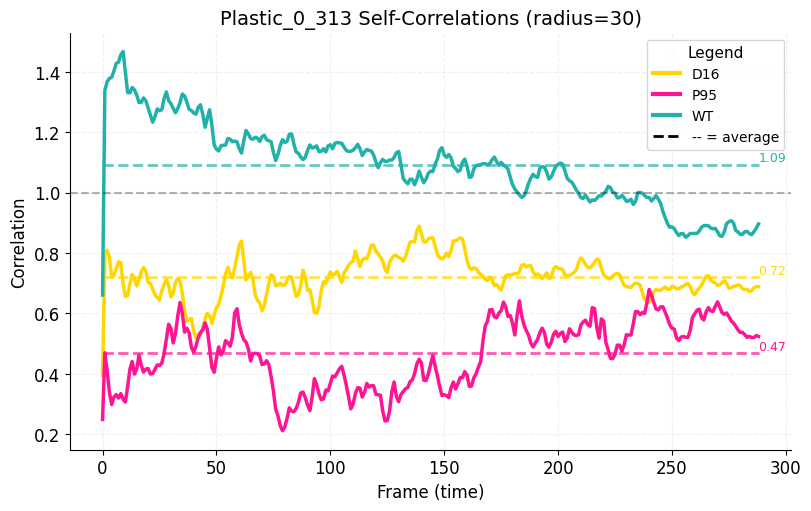

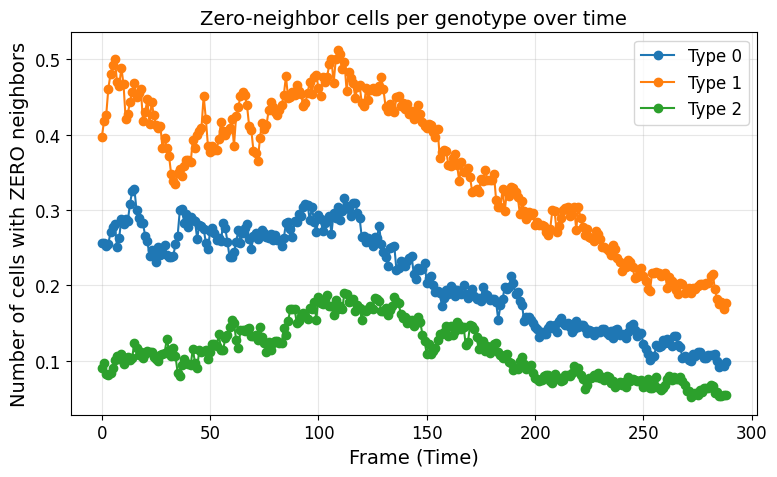

In [232]:
# Self-correlations only

frames_joint, corr_matrices_joint, zero_counts_joint = correlations_by_framez(temp_df, 'frame', 'x_microns', 'y_microns', 'phenotype', N=3, radius=30, normalization="p_joint", return_zero_counts=True)
plot_self_correlations(frames_joint, corr_matrices_joint, dataset_name="Plastic_0_313", radius=30, N=3, window=2,save_path="./images/")
plot_zero_counts(frames_joint, zero_counts_joint)





In [ ]:
# Dictionary to store results
coculture_corr= {}

# Loop through all DataFrames in c_dfs
for key, df in c_dfs.items():
    try:
        # Compute correlations per frame
        frames, corr_matrices = correlations_by_frame(
            df,
            frame_col='frame',       # adjust if your frame column has a different name
            x_col='x_microns',       # adjust if your x column is named differently
            y_col='y_microns',       # adjust if your y column is named differently
            label_col='phenotype',   # column with phenotype labels
            N=3,                     # number of phenotypes
            radius=50,                # neighborhood radius
            normalization="p_joint"  # use p-joint normalization
        )
        coculture_corr[key] = {
            'frames': frames,
            'corr_matrices': corr_matrices,
            'coating': c_dfs[key]['coating'].iloc[0],
            'initial_density': c_dfs[key]['initial_density'].iloc[0]
        }
    except Exception as e:
        print(f"Error processing {key}: {e}")



KeyboardInterrupt: 

In [12]:
# Dictionary to store results
coculture_corr2= {}

# Loop through all DataFrames in c_dfs
for key, df in c_dfs.items():
    try:
        # Compute correlations per frame
        frames, corr_matrices, zero_counts_joint = correlations_by_framez(
            df,
            frame_col='frame',       # adjust if your frame column has a different name
            x_col='x_microns',       # adjust if your x column is named differently
            y_col='y_microns',       # adjust if your y column is named differently
            label_col='phenotype',   # column with phenotype labels
            N=3,                     # number of phenotypes
            radius=50,                # neighborhood radius
            normalization="p_joint",  # use p-joint normalization
            return_zero_counts=True   # return zero counts
        )
        coculture_corr2[key] = {
            'frames': frames,
            'corr_matrices': corr_matrices,
            'coating': c_dfs[key]['coating'].iloc[0],
            'initial_density': c_dfs[key]['initial_density'].iloc[0],
            'zero_counts_joint': zero_counts_joint
        }
    except Exception as e:
        print(f"Error processing {key}: {e}")


In [13]:
summary_data2 = []

for key, result in coculture_corr2.items():
    corr_matrices = result['corr_matrices']

    # Remove any bad matrices
    valid_mats = [mat for mat in corr_matrices if not np.isnan(mat).any()]
    corr_stack = np.stack(valid_mats)

    median_corr = np.nanmedian(corr_stack, axis=0)
    mean_corr = np.nanmean(corr_stack, axis=0)
    count_corr = np.sum(~np.isnan(corr_stack), axis=0)

    # Pull experiment, coating, and initial density
    row = {
        'experiment': key,
        'coating': result['coating'],
        'initial_density': result['initial_density']
    }

    # Store mean correlations for each phenotype pairing
    N = mean_corr.shape[0]
    for i in range(N):
        for j in range(i, N):
            row[f'{i}-{j}'] = mean_corr[i, j]
    for i in range(N):
        row[f'zero_count_{i}'] = np.mean([zc[i] for zc in result['zero_counts_joint']])

    summary_data2.append(row)

summary_df2 = pd.DataFrame(summary_data2)
save_path = ".../data/coculture_correlation_50.csv"

import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)

summary_df2.to_csv(save_path, index=False)
summary_df2


,experiment,coating,initial_density,0-0,0-1,0-2,1-1,1-2,2-2,zero_count_0,zero_count_1,zero_count_2
0,Fibronectin_0_625_-40-F5-F05,Fibronectin,0.625,0.466300,0.462178,0.844127,0.354652,0.331074,3.173514,0.641094,0.756657,0.236244
1,Fibronectin_0_625_-41-F6-F06,Fibronectin,0.625,0.715427,0.770239,1.101325,0.689425,1.045839,2.545953,0.666112,0.703740,0.433311
2,Fibronectin_0_625_-42-F7-F07,Fibronectin,0.625,0.791665,0.388371,0.786342,0.768847,0.555466,2.561619,0.600076,0.721150,0.368278
3,Plastic_0_313_-46-G2-G02,Plastic,0.313,0.610802,0.633860,1.010240,0.648314,1.258053,1.774953,0.380094,0.476332,0.193757
4,Plastic_0_313_-47-G3-G03,Plastic,0.313,0.670563,0.865720,1.155978,0.494190,0.736049,2.354303,0.376828,0.499623,0.169400
5,Plastic_0_313_-48-G4-G04,Plastic,0.313,0.785178,0.696490,1.083546,0.517430,1.161041,2.237158,0.434150,0.508692,0.237500
6,Fibronectin_10_-04-B5-B05,Fibronectin,10.000,0.702140,1.068764,1.277255,0.504184,0.973179,0.825459,0.005178,0.024924,0.004212
7,Fibronectin_10_-05-B6-B06,Fibronectin,10.000,0.659009,0.968438,1.306180,0.426954,1.032242,0.881559,0.020509,0.067174,0.008346
8,Fibronectin_10_-06-B7-B07,Fibronectin,10.000,0.643654,1.141850,1.231755,0.603294,1.139024,0.744145,0.000284,0.001820,0.000305
9,PDK_0_313_-52-G8-G08,PDK,0.313,0.628012,0.287309,1.267627,0.699054,1.144075,2.556515,0.538875,0.609883,0.289157


In [ ]:
summary_data = []

for key, result in coculture_corr.items():
    corr_matrices = result['corr_matrices']

    # Remove any bad matrices
    valid_mats = [mat for mat in corr_matrices if not np.isnan(mat).any()]
    corr_stack = np.stack(valid_mats)

    median_corr = np.nanmedian(corr_stack, axis=0)
    mean_corr = np.nanmean(corr_stack, axis=0)
    count_corr = np.sum(~np.isnan(corr_stack), axis=0)

    # Pull experiment, coating, and initial density
    row = {
        'experiment': key,
        'coating': result['coating'],
        'initial_density': result['initial_density']
    }

    # Store mean correlations for each phenotype pairing
    N = mean_corr.shape[0]
    for i in range(N):
        for j in range(i, N):
            row[f'{i}-{j}'] = mean_corr[i, j]

    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df





,experiment,coating,initial_density,0-0,0-1,0-2,1-1,1-2,2-2
0,Fibronectin_0_625_-40-F5-F05,Fibronectin,0.625,0.466300,0.462178,0.844127,0.354652,0.331074,3.173514
1,Fibronectin_0_625_-41-F6-F06,Fibronectin,0.625,0.715427,0.770239,1.101325,0.689425,1.045839,2.545953
2,Fibronectin_0_625_-42-F7-F07,Fibronectin,0.625,0.791665,0.388371,0.786342,0.768847,0.555466,2.561619
3,Plastic_0_313_-46-G2-G02,Plastic,0.313,0.610802,0.633860,1.010240,0.648314,1.258053,1.774953
4,Plastic_0_313_-47-G3-G03,Plastic,0.313,0.670563,0.865720,1.155978,0.494190,0.736049,2.354303
5,Plastic_0_313_-48-G4-G04,Plastic,0.313,0.785178,0.696490,1.083546,0.517430,1.161041,2.237158
6,Fibronectin_10_-04-B5-B05,Fibronectin,10.000,0.702140,1.068764,1.277255,0.504184,0.973179,0.825459
7,Fibronectin_10_-05-B6-B06,Fibronectin,10.000,0.659009,0.968438,1.306180,0.426954,1.032242,0.881559
8,Fibronectin_10_-06-B7-B07,Fibronectin,10.000,0.643654,1.141850,1.231755,0.603294,1.139024,0.744145
9,PDK_0_313_-52-G8-G08,PDK,0.313,0.628012,0.287309,1.267627,0.699054,1.144075,2.556515


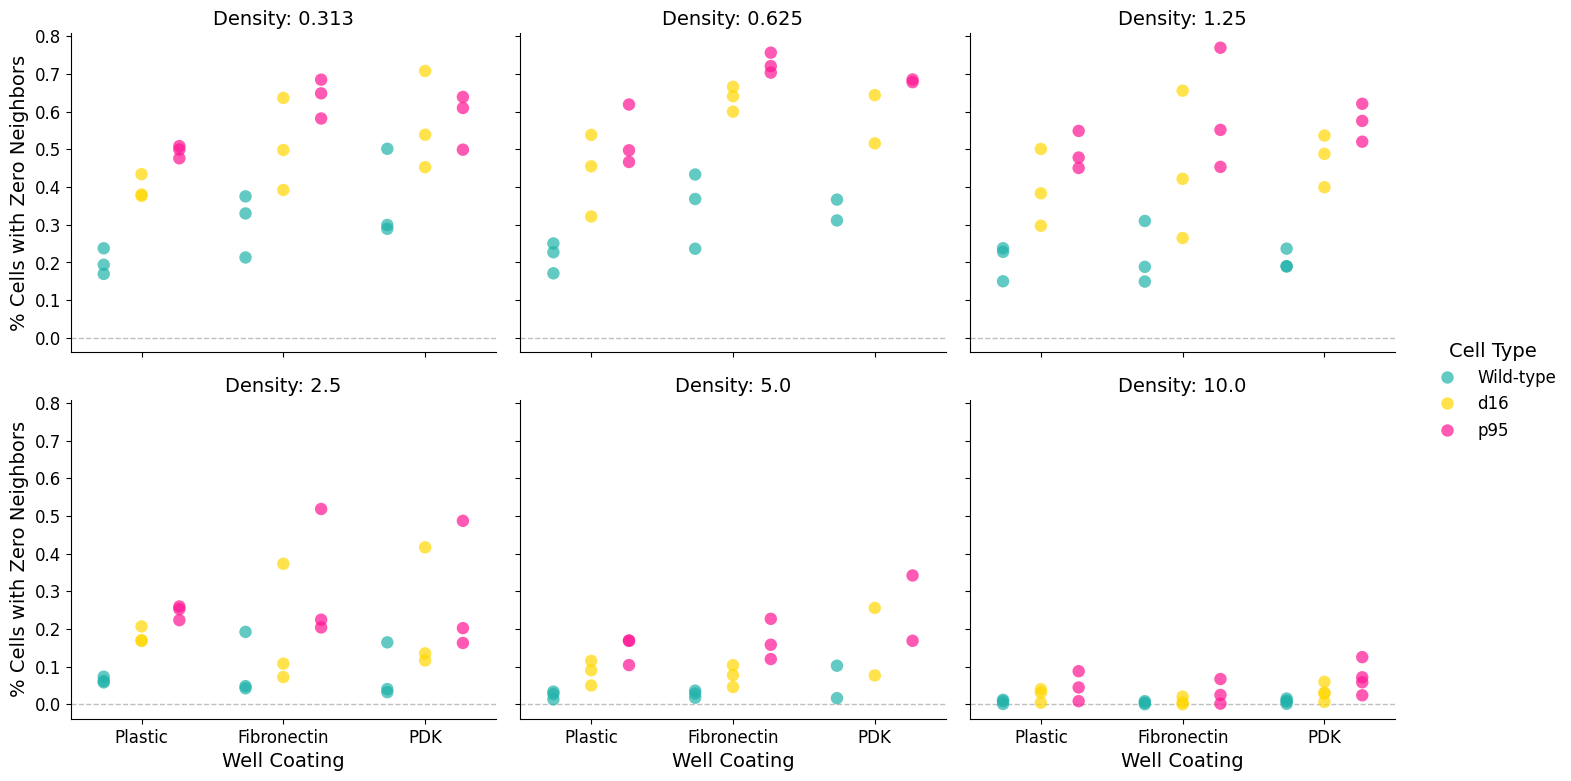

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make a copy to avoid modifying original DataFrame
plot_df = summary_df2.copy()

# Map zero-count columns to genotypes
label_map = {
    'zero_count_0': 'd16',
    'zero_count_1': 'p95',
    'zero_count_2': 'Wild-type'
}

palette_genotype = {
    'Wild-type': 'lightseagreen',
    'd16': 'gold',
    'p95': 'deeppink'
}

# Convert wide → long format, but using zero counts this time
plot_df_long = plot_df.melt(
    id_vars=['initial_density', 'coating', 'experiment'],
    value_vars=['zero_count_0', 'zero_count_1', 'zero_count_2'],
    var_name='pairing',
    value_name='zero_count'
)

# Map genotype names
plot_df_long['genotype'] = plot_df_long['pairing'].map(label_map)

# Sort densities low → high
densities_sorted = sorted(plot_df['initial_density'].unique())
plot_df_long['initial_density'] = pd.Categorical(
    plot_df_long['initial_density'].astype(str),
    categories=[str(d) for d in densities_sorted],
    ordered=True
)

# Larger fonts
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# --- Create strip plot FacetGrid faceted by initial_density ---
g = sns.catplot(
    data=plot_df_long,
    x='coating',
    y='zero_count',            # ← CHANGED
    hue='genotype',
    col='initial_density',
    col_wrap=3,
    kind='strip',
    palette=palette_genotype,
    height=4,
    aspect=1.2,
    legend='auto',
    hue_order=['Wild-type', 'd16', 'p95'],
    order=['Plastic', 'Fibronectin', 'PDK'],
    s=80,
    dodge=True,
    jitter=False,
    alpha=0.7,
    edgecolor='black',
)

# --- Beautify labels and layout ---
g.set_axis_labels("Well Coating", "% Cells with Zero Neighbors")   # ← CHANGED LABEL
g.set_titles(col_template="Density: {col_name}")
g.tight_layout(pad=1)
g._legend.set_title("Cell Type")

# Optional horizontal reference line (use y=0 instead of y=1)
for ax in g.axes.flat:
    ax.axhline(0, color='gray', ls='--', linewidth=1, alpha=0.5)

plt.show()




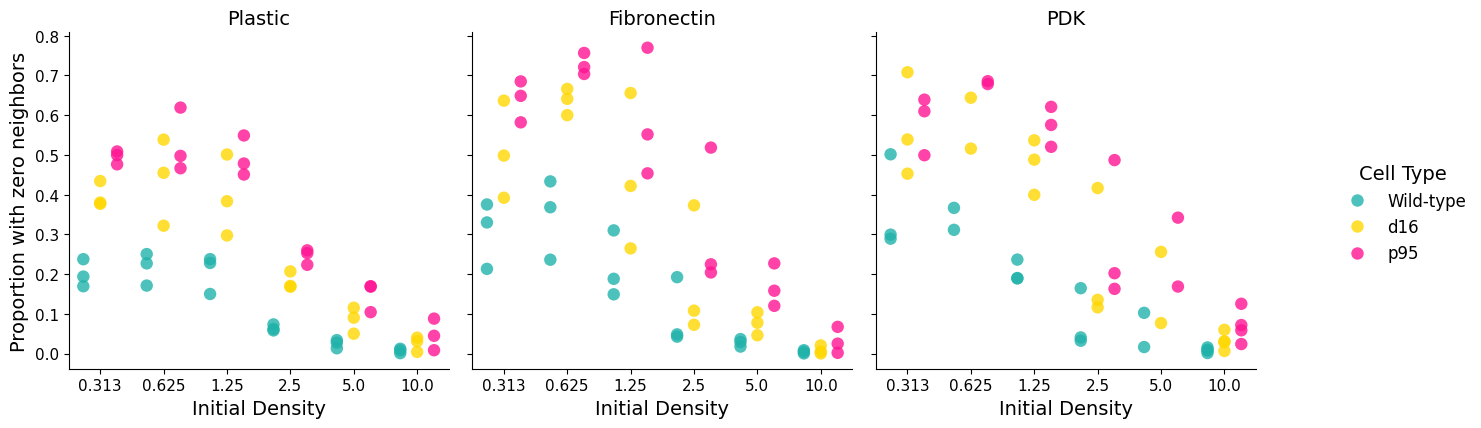

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make a copy to avoid modifying original DataFrame
plot_df = summary_df2.copy()

# Map zero-count columns to genotypes
label_map = {
    'zero_count_0': 'd16',
    'zero_count_1': 'p95',
    'zero_count_2': 'Wild-type'
}

palette_genotype = {
    'Wild-type': 'lightseagreen',
    'd16': 'gold',
    'p95': 'deeppink'
}

# Convert wide → long format
plot_df_long = plot_df.melt(
    id_vars=['initial_density', 'coating', 'experiment'],
    value_vars=['zero_count_0', 'zero_count_1', 'zero_count_2'],
    var_name='pairing',
    value_name='zero_count'
)

# Map genotype names
plot_df_long['genotype'] = plot_df_long['pairing'].map(label_map)

# Convert to categorical for nicer plotting
plot_df_long['initial_density'] = plot_df_long['initial_density'].astype(str)

# Font sizes
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
})

# --- Plot ---
g = sns.catplot(
    data=plot_df_long,
    x='initial_density',
    y='zero_count',
    hue='genotype',
    col='coating',
    kind='strip',
    palette=palette_genotype,
    height=4.5,
    aspect=1.0,
    legend='auto',
    hue_order=['Wild-type', 'd16', 'p95'],
    col_order=['Plastic', 'Fibronectin', 'PDK'],  # keep order
    order=['0.313', '0.625', '1.25', '2.5', '5.0', '10.0'],
    s=80,
    dodge=True,
    jitter=False,
    alpha=0.8
)

# Axis labels and titles
g.set_axis_labels("Initial Density", "Proportion with zero neighbors")
g.set_titles(col_template="{col_name}")
g.tight_layout(pad=1)
g._legend.set_title("Cell Type")

plt.subplots_adjust(top=0.9, right=0.85)
plt.show()


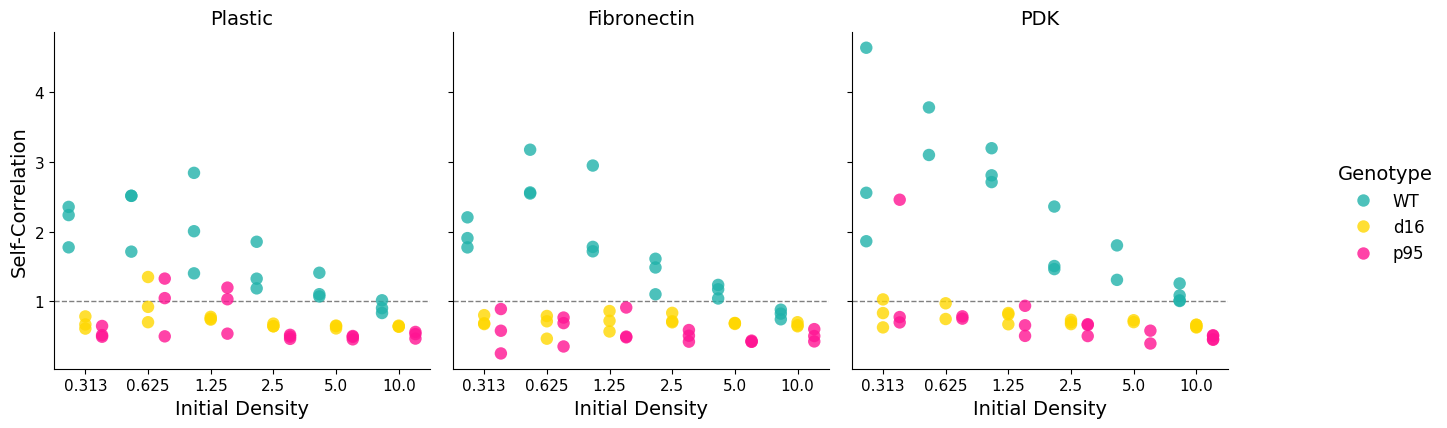

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make a copy to avoid modifying original DataFrame
plot_df = summary_df2.copy()

# Map correlation matrix labels to genotypes
label_map = {
    '0-0': 'd16',
    '1-1': 'p95',
    '2-2': 'WT'
}

palette_genotype = {
    'WT': 'lightseagreen',
    'd16': 'gold',
    'p95': 'deeppink'
}

# Convert wide to long format for plotting
plot_df_long = plot_df.melt(
    id_vars=['initial_density', 'coating', 'experiment'],
    value_vars=['0-0', '1-1', '2-2'],
    var_name='pairing',
    value_name='correlation'
)

# Map genotype names
plot_df_long['genotype'] = plot_df_long['pairing'].map(label_map)

# Convert initial_density to string to make it categorical
plot_df_long['initial_density'] = plot_df_long['initial_density'].astype(str)

# Larger fonts
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
})

# --- Create box plot FacetGrid ---
g = sns.catplot(
    data=plot_df_long,
    x='initial_density',
    y='correlation',
    hue='genotype',
    col='coating',
    kind='strip',  # Changed from 'strip' to 'box'
    palette=palette_genotype,
    height=4.5,
    aspect=1.0,
    legend='auto',
    hue_order=['WT', 'd16', 'p95'],
    col_order=['Plastic', 'Fibronectin', 'PDK'],
    order=['0.313', '0.625', '1.25', '2.5', '5.0', '10.0'],
    s=80,
    dodge=True,
    jitter=False,
    alpha=0.8
)

# --- Beautify labels and layout ---
g.set_axis_labels("Initial Density", "Self-Correlation")
g.set_titles(col_template="{col_name}")
g.tight_layout(pad=1)
g._legend.set_title("Genotype")


# Horizontal line at y = 1
for ax in g.axes.flat:
    ax.axhline(1, color='gray', ls='--', linewidth=1)

plt.subplots_adjust(top=0.9, right=0.85)
plt.show()

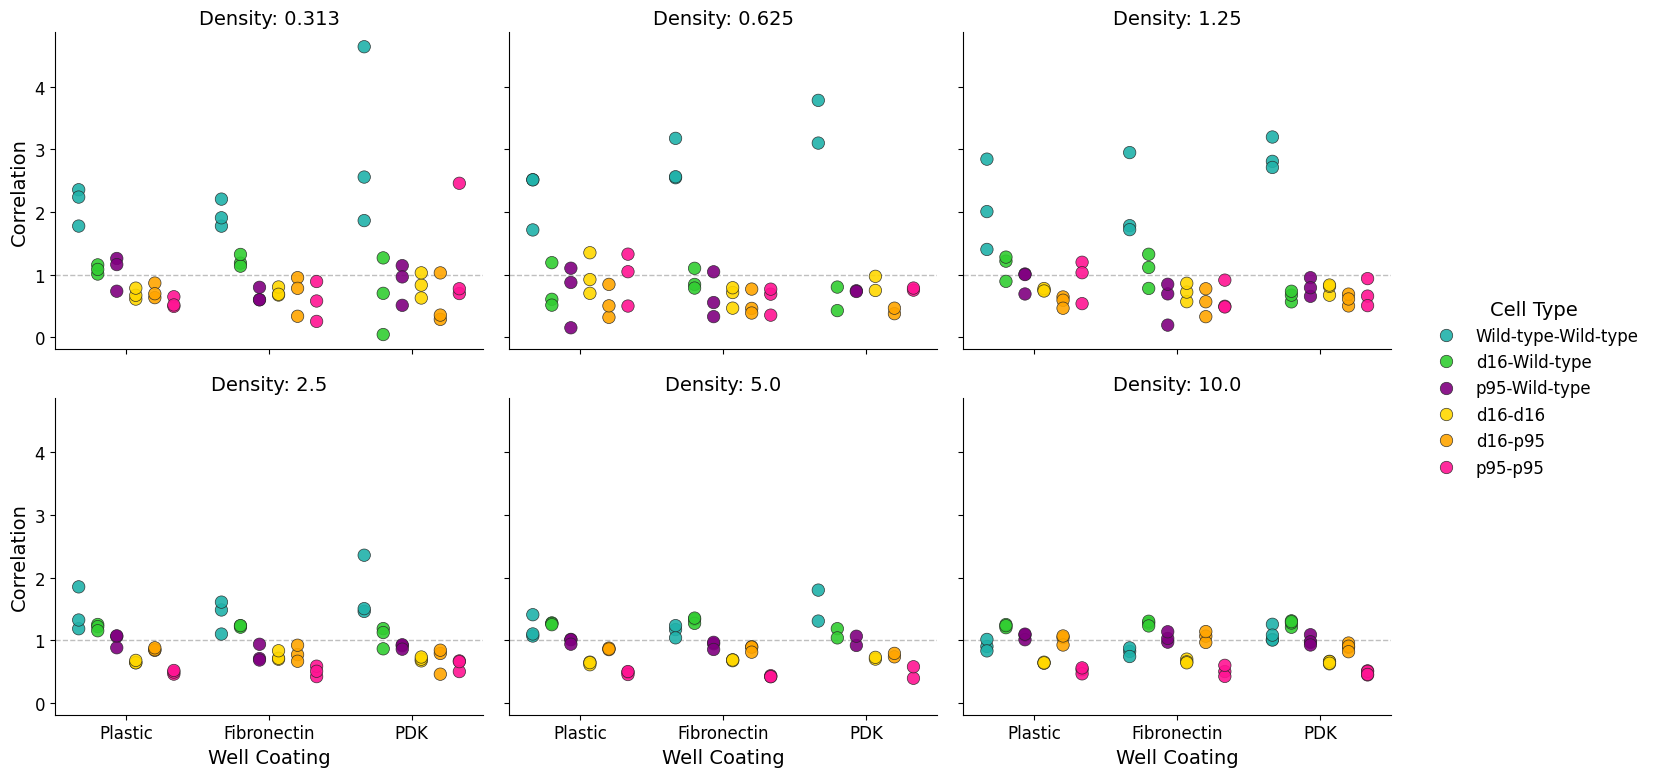

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make a copy to avoid modifying original DataFrame
plot_df = summary_df2.copy()

# Map correlation matrix labels to genotypes
label_map = {
    '0-0': 'd16-d16',
    '1-1': 'p95-p95',
    '2-2': 'Wild-type-Wild-type',
    '0-1': 'd16-p95',
    '0-2': 'd16-Wild-type',
    '1-2': 'p95-Wild-type'
}

palette_genotype = {
    'Wild-type-Wild-type': 'lightseagreen',
    'd16-d16': 'gold',
    'p95-p95': 'deeppink',
    'd16-p95': 'orange',
    'd16-Wild-type': 'limegreen',
    'p95-Wild-type': 'purple'

}

# Convert wide to long format for plotting
plot_df_long = plot_df.melt(
    id_vars=['initial_density', 'coating', 'experiment'],
    value_vars=['0-0', '1-1', '2-2', '0-1', '0-2', '1-2'],
    var_name='pairing',
    value_name='correlation'
)

# Map genotype names
plot_df_long['genotype'] = plot_df_long['pairing'].map(label_map)

# Larger fonts
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# --- Create strip plot FacetGrid faceted by initial_density ---
g = sns.catplot(
    data=plot_df_long,
    x='coating',
    y='correlation',
    hue='genotype',
    col='initial_density',  # Changed: now faceting by density
    col_wrap=3,  # 3 columns per row
    kind='strip',
    palette=palette_genotype,
    height=4,
    aspect=1.2,
    legend='auto',
    hue_order=['Wild-type-Wild-type', 'd16-Wild-type', 'p95-Wild-type', 'd16-d16', 'd16-p95', 'p95-p95'],
    order=['Plastic', 'Fibronectin', 'PDK'],
    s=80,
    dodge=True,
    jitter=False,
    alpha=0.9,
    linewidth=0.5
)

                
# --- Beautify labels and layout ---
g.set_axis_labels("Well Coating", "Correlation")
g.set_titles(col_template="Density: {col_name}")
g.tight_layout(pad=1)
g._legend.set_title("Genotype")

# Horizontal line at y = 1
for ax in g.axes.flat:
    ax.axhline(1, color='gray', ls='--', linewidth=1, alpha=0.5)

g.tight_layout()
plt.show()



In [300]:
from sklearn.neighbors import KDTree
! pip show scikit-learn


Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /home/msadeck/.pyenv/versions/eql3119/lib/python3.11/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: pynndescent, scanpy, spatialdata-plot, squidpy, umap-learn


In [303]:
import scanpy as sc
import numpy as np

# Make sure your phenotype column is categorical
df_frame['phenotype'] = df_frame['phenotype'].astype('category')

# Minimal expression matrix (Squidpy requires X, can be dummy)
X = np.zeros((df_frame.shape[0], 1))

# Create AnnData
adata = sc.AnnData(X=X, obs=df_frame.copy())

# Add spatial coordinates
adata.obsm["spatial"] = df_frame[["x", "y"]].to_numpy()

# Inspect
adata


/home/msadeck/.pyenv/versions/3.11.9/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 867 × 1
    obs: 'frame', 'y', 'x', 'particle', 'area', 'equiv_diameter', 'mean_c0', 'mean_c1', 'mean_c2', 'std_c0', 'std_c1', 'std_c2', 'color', 'experiment', 'initial_density', 'coating', 'x_microns', 'y_microns', 'phenotype'
    obsm: 'spatial'

In [302]:
# Choose the frame you want
frame_number = 0

# Subset the DataFrame
df_frame = temp_df[temp_df['frame'] == frame_number].copy()

# Inspect
df_frame.head()


,frame,y,x,particle,area,equiv_diameter,mean_c0,mean_c1,mean_c2,std_c0,std_c1,std_c2,color,experiment,initial_density,coating,x_microns,y_microns,phenotype
0,0,1.796296,29.685185,0,54.0,8.291860,39.277778,40.574074,39.814815,1.043794,1.408990,1.375366,T,-01-B2-B02,10,Plastic,40.846815,2.471704,2
1,0,3.047297,125.033784,1,148.0,13.727325,52.385135,40.918919,42.668919,11.641331,1.377981,3.397910,M,-01-B2-B02,10,Plastic,172.046486,4.193081,1
2,0,2.333333,143.146667,2,75.0,9.772050,49.933333,41.173333,42.533333,16.072613,2.211324,5.241713,M,-01-B2-B02,10,Plastic,196.969813,3.210667,1
3,0,4.687500,301.398438,3,128.0,12.766153,39.171875,42.984375,42.039062,1.403730,2.304833,2.115428,T,-01-B2-B02,10,Plastic,414.724250,6.450000,2
4,0,5.644970,314.715976,4,169.0,14.668929,39.213018,42.224852,41.313609,1.221919,1.712218,1.484394,T,-01-B2-B02,10,Plastic,433.049183,7.767479,2


In [ ]:
import squidpy as sq

cooccurrences, distances = sq.gr.co_occurrence(
    adata,
    cluster_key="phenotype",  
    spatial_key="spatial",   
    interval= [25, 50, 75, 100],  
    copy=True,                
)


In [312]:
# Ensure categorical
adata.obs['phenotype'] = adata.obs['phenotype'].astype('category')

# Get the list of phenotype labels
phenotypes = adata.obs['phenotype'].cat.categories

# Example: index of specific phenotypes
i = list(phenotypes).index('M')
j = list(phenotypes).index('M')

# Now you can access co-occurrence
cooccurrences[i, j, :]  # all distance bins


ValueError: 'M' is not in list